In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt





In [17]:
# 1. Laden der Daten
data = pd.read_csv("../../data/predictive_maintenance.csv")

In [18]:

# 2. Encoding der kategorialen Variablen und Skalierung der Features
categorical_features = ['Type']
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()

# Feature Engineering: Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('poly', poly)
        ]), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])



In [19]:
# 3. Aufteilung der Daten in Trainings- und Testdatensätze
X = data.drop(columns=["Failure Type"])  # select Features 
y = data["Failure Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Überprüfen der Pipeline
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)



(8000, 38)
(2000, 38)


In [20]:
# 4. Training des GradientBoosting-Modells mit Hyperparameter-Tuning
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define the hyperparameter grid
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5],
    'classifier__subsample': [0.8, 0.9, 1.0],
    'classifier__min_samples_split': [2, 5, 10]
}

# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, scoring='accuracy', n_jobs=-1, cv=3, random_state=42)
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

# Fit the best model
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['UDI', 'Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Target']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Type'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.01,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [21]:
# 5. Evaluierung des Modells
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", classification_rep)


Accuracy: 0.9935
Classification Report:
                           precision    recall  f1-score   support

Heat Dissipation Failure       0.87      0.87      0.87        15
              No Failure       1.00      1.00      1.00      1935
      Overstrain Failure       0.80      0.92      0.86        13
           Power Failure       1.00      0.95      0.97        20
         Random Failures       0.00      0.00      0.00         6
       Tool Wear Failure       1.00      0.82      0.90        11

                accuracy                           0.99      2000
               macro avg       0.78      0.76      0.77      2000
            weighted avg       0.99      0.99      0.99      2000



/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

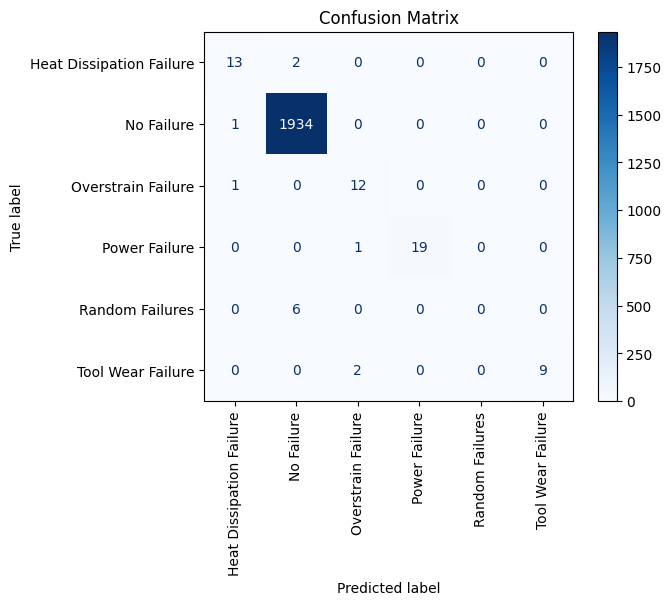

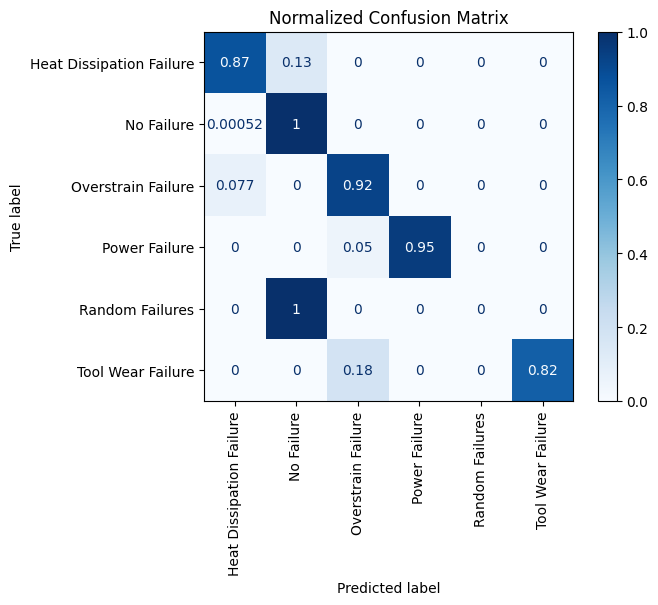

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test and y_pred are defined
# y_test = ...
# y_pred = ...

# Define your label names
labels = ['Heat Dissipation Failure', 'No Failure', 'Overstrain Failure', 'Power Failure', 'Random Failures', 'Tool Wear Failure']

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Compute normalized confusion matrix
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Plot normalized confusion matrix with labels
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp_normalized.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Normalized Confusion Matrix')
plt.show()


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('../../data/predictive_maintenance.csv')

# Data Preprocessing
# Handle missing values if any
data.fillna(method='ffill', inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder()
data['Failure Type'] = label_encoder.fit_transform(data['Failure Type'])

# Drop unnecessary columns
data = data.drop(columns=['UDI', 'Product ID', 'Type', 'Target'])

# Split features and target
X = data.drop('Failure Type', axis=1)
y = data['Failure Type']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model
model = GradientBoostingClassifier(random_state=42)

# Hyperparameter tuning with reduced iterations
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 0.9],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, scoring='accuracy', n_jobs=-1, cv=3, random_state=42)
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


/var/folders/vr/klm94mws7lsd0vj7h5gd2bqw0000gn/T/ipykernel_4607/839365804.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


Accuracy: 0.9815
              precision    recall  f1-score   support

           0       1.00      0.73      0.85        15
           1       0.99      1.00      0.99      1935
           2       0.73      0.62      0.67        13
           3       0.79      0.75      0.77        20
           4       0.00      0.00      0.00         6
           5       0.00      0.00      0.00        11

    accuracy                           0.98      2000
   macro avg       0.58      0.52      0.55      2000
weighted avg       0.97      0.98      0.98      2000



/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz